In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import time

import optuna
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes


from qiskit_aer import AerSimulator


from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import SPSA

from qiskit.primitives import BackendSampler
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold

from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Definir la ruta base de los archivos de datos
base_dir = r"/home/daniel/Desktop/TFG/nsl-kdd"

# Definir las rutas completas de los archivos de entrenamiento y prueba
train_path = os.path.join(base_dir, "KDDTrain+.txt")
test_path = os.path.join(base_dir, "KDDTest+.txt")

# Nombres de las columnas
column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds",
    "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty"
]

# Cargar los datos en dataframes
train = pd.read_csv(train_path, names=column_names)
test = pd.read_csv(test_path, names=column_names)

# Añadir la columna 'class': 0 para normal, 1 para anomalía
train['class'] = train['label'].apply(lambda x: 0 if x == 'normal' else 1)
test['class'] = test['label'].apply(lambda x: 0 if x == 'normal' else 1)

# Mostrar las primeras líneas del dataframe de entrenamientotrain.head()
train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20,0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,1
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,0
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,0


In [3]:
train.info() #Información sobre el dataframe de entrenamiento

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 44 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [4]:
train.describe() #Driscripciones del dataframe de entrenamiento para columnas numéricas


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty,class
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060,0.465417
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503,0.498805
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000,1.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000,1.000000


In [5]:
train.describe(include='object') #Descripciones del dataframe de entrenamiento para columnas categóricas

,protocol_type,service,flag,label
count,125973,125973,125973,125973
unique,3,70,11,23
top,tcp,http,SF,normal
freq,102689,40338,74945,67343


In [6]:
train.shape #Tamaño del dataframe de entrenamiento

(125973, 44)

In [7]:
train.isnull().sum() #Contar el numero de valores nulos en cada columan del dataframe de entrenamiento

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

class
0    67343
1    58630
Name: count, dtype: int64


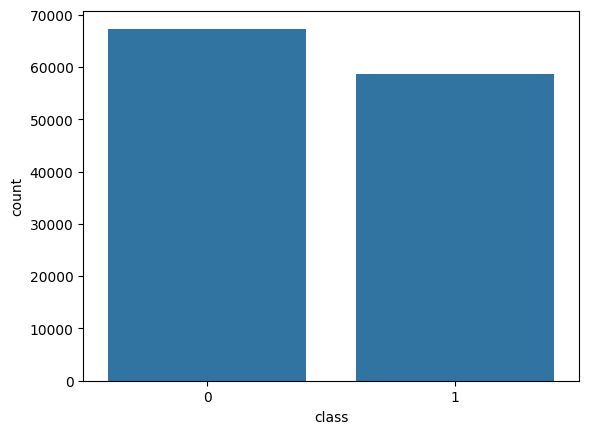

In [8]:
sns.countplot(x=train['class'])
print(train['class'].value_counts())

In [9]:
columns_to_drop = ['difficulty', 'num_outbound_cmds']
train.drop(columns=columns_to_drop, axis=1, inplace=True)
test.drop(columns=columns_to_drop, axis=1, inplace=True)


train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,1
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,0
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,0


In [10]:
def cod(df):
    for col in df.columns:
        if df[col].dtype == 'object': #Búsqueda de variables categóricas
            label_encoder = LabelEncoder() #Conversor de variables categóricas a variables numéricas
            df[col] = label_encoder.fit_transform(df[col])

cod(train)
cod(test)

In [11]:
from sklearn.feature_selection import SelectKBest, f_classif


# Separar las características (X) y la variable objetivo (Y)
X_train = train.drop(['class', 'label'], axis=1)
Y_train = train['class']
X_test = test.drop(['class', 'label'], axis=1)
Y_test = test['class']

# Inicializar el selector SelectKBest con la función ANOVA F-score para clasificación
selector = SelectKBest(score_func=f_classif, k=8)  

# Ajustar el selector a los datos de entrenamiento
selector.fit(X_train, Y_train)

# Obtener las características seleccionadas
selected_mask = selector.get_support()  # Booleano para cada columna
featureMap = [(i, v) for i, v in zip(selected_mask, X_train.columns)]
selectFeatures = [v for i, v in featureMap if i]

print(selectFeatures)


X_train = X_train[selectFeatures] #Filtrar el dataframe de entrenamiento para incluir solo las caractrísticas seleccionadas
X_test = X_test[selectFeatures]

['logged_in', 'serror_rate', 'srv_serror_rate', 'same_srv_rate', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate']


In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Volver a convertir en DataFrame para usar .iloc después
X_train = pd.DataFrame(X_train, columns=selectFeatures)
X_test = pd.DataFrame(X_test, columns=selectFeatures)

# Barajar train y test con las etiquetas al mismo tiempo
train_shuffled = X_train.copy()
train_shuffled["label"] = Y_train.values
train_shuffled = train_shuffled.sample(frac=1, random_state=42).reset_index(drop=True)

test_shuffled = X_test.copy()
test_shuffled["label"] = Y_test.values
test_shuffled = test_shuffled.sample(frac=1, random_state=42).reset_index(drop=True)

# Separar de nuevo X e y
X_train = train_shuffled.drop("label", axis=1).iloc[:1000]
Y_train = train_shuffled["label"].iloc[:1000]

X_test = test_shuffled.drop("label", axis=1).iloc[:500]
Y_test = test_shuffled["label"].iloc[:500]

In [13]:
RANDOM_STATE = 42 
CV_FOLDS = 5
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)



In [14]:
startEx = time.time()

def objective_vqc(trial):
    # Hiperparámetros a optimizar
    reps_feature_map = trial.suggest_int('reps_feature_map', 1, 3)
    shots = trial.suggest_categorical('shots', [250, 512, 1024, 2048])
    reps_ansatz = trial.suggest_int('reps_ansatz', 1, 3)
    optimizer_maxiter = trial.suggest_int('optimizer_maxiter', 50, 200)
    optimizer_lr = trial.suggest_float('optimizer_lr', 0.001, 0.1, log=True)
    optimizer_pert = trial.suggest_float('optimizer_pert', 0.001, 0.1, log=True)
    print(f"Empezando trial {trial.number} con parámetros: reps_feature_map={reps_feature_map}, reps_ansatz={reps_ansatz}, shots={shots}, optimizer_maxiter={optimizer_maxiter}, optimizer_lr={optimizer_lr:.5f}, optimizer_pert={optimizer_pert:.5f}")

    # Construcción feature map y ansatz
    feature_map = ZZFeatureMap(feature_dimension=X_train.shape[1], reps=reps_feature_map, entanglement='linear')
    ansatz = RealAmplitudes(num_qubits=X_train.shape[1], reps=reps_ansatz)
    
    # Simulador con shots
    backend = AerSimulator()
    backend.set_options(shots=shots)
    sampler = BackendSampler(backend) 

    # Optimizer clásico
    optimizer = SPSA(maxiter=optimizer_maxiter, learning_rate=optimizer_lr, perturbation=optimizer_pert)
    
    # Modelo VQC
    model = VQC(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=optimizer,
        sampler=sampler
    )
    
    scores = []
    for train_idx, val_idx in skf.split(X_train, Y_train):
        model.fit(X_train.iloc[train_idx].to_numpy(), Y_train.iloc[train_idx].to_numpy())
        preds = model.predict(X_train.iloc[val_idx].to_numpy())
        score = f1_score(Y_train.iloc[val_idx], preds, average='macro')
        scores.append(score)
    return np.mean(scores)


study_vqc = optuna.create_study(direction='maximize')
study_vqc.optimize(objective_vqc, n_trials=15)

print("Mejores parámetros encontrados VQC:", study_vqc.best_params)

[I 2025-08-28 17:22:03,378] A new study created in memory with name: no-name-d69612b6-d418-4608-8016-a7d2d52d2def


Empezando trial 0 con parámetros: reps_feature_map=2, reps_ansatz=2, shots=512, optimizer_maxiter=166, optimizer_lr=0.05773, optimizer_pert=0.00114


[I 2025-08-28 23:40:25,073] Trial 0 finished with value: 0.8076138472447688 and parameters: {'reps_feature_map': 2, 'shots': 512, 'reps_ansatz': 2, 'optimizer_maxiter': 166, 'optimizer_lr': 0.05772717462282089, 'optimizer_pert': 0.0011373789046785448}. Best is trial 0 with value: 0.8076138472447688.


Empezando trial 1 con parámetros: reps_feature_map=3, reps_ansatz=1, shots=250, optimizer_maxiter=64, optimizer_lr=0.01266, optimizer_pert=0.00112


[I 2025-08-29 02:09:55,353] Trial 1 finished with value: 0.46639190833018745 and parameters: {'reps_feature_map': 3, 'shots': 250, 'reps_ansatz': 1, 'optimizer_maxiter': 64, 'optimizer_lr': 0.012660134515665018, 'optimizer_pert': 0.001115521330962397}. Best is trial 0 with value: 0.8076138472447688.


...

Empezando trial 13 con parámetros: reps_feature_map=1, reps_ansatz=2, shots=2048, optimizer_maxiter=93, optimizer_lr=0.09998, optimizer_pert=0.07521


[I 2025-08-30 06:54:03,703] Trial 13 finished with value: 0.8066614013520941 and parameters: {'reps_feature_map': 1, 'shots': 2048, 'reps_ansatz': 2, 'optimizer_maxiter': 93, 'optimizer_lr': 0.0999807009288077, 'optimizer_pert': 0.07520785195882422}. Best is trial 0 with value: 0.8076138472447688.


Empezando trial 14 con parámetros: reps_feature_map=2, reps_ansatz=3, shots=512, optimizer_maxiter=148, optimizer_lr=0.00883, optimizer_pert=0.01718


[I 2025-08-30 08:25:34,584] Trial 14 finished with value: 0.3669955419454335 and parameters: {'reps_feature_map': 2, 'shots': 512, 'reps_ansatz': 3, 'optimizer_maxiter': 148, 'optimizer_lr': 0.008831213101261582, 'optimizer_pert': 0.01717575623318197}. Best is trial 0 with value: 0.8076138472447688.


Mejores parámetros encontrados VQC: {'reps_feature_map': 2, 'shots': 512, 'reps_ansatz': 2, 'optimizer_maxiter': 166, 'optimizer_lr': 0.05772717462282089, 'optimizer_pert': 0.0011373789046785448}


In [15]:
best_params = study_vqc.best_params

feature_map_final = ZZFeatureMap(
    feature_dimension=X_train.shape[1], 
    reps=best_params['reps_feature_map'], 
    entanglement='linear'
)
ansatz_final = RealAmplitudes(
    num_qubits=X_train.shape[1], 
    reps=best_params['reps_ansatz']
    
)
optimizer_final = SPSA(
    maxiter=best_params['optimizer_maxiter'], 
    learning_rate=best_params['optimizer_lr'],
    perturbation= best_params['optimizer_pert']
)
backend = AerSimulator()
backend.set_options(shots=best_params['shots'])
sampler = BackendSampler(backend) 

VQC_model = VQC(
    feature_map=feature_map_final,
    ansatz=ansatz_final,
    optimizer=optimizer_final,
    sampler=sampler
)

start_train = time.time()
VQC_model.fit(X_train.to_numpy(), Y_train.to_numpy())
end_train = time.time()
print(f"⏱ Tiempo de entrenamiento VQC: {end_train - start_train:.4f} segundos")

start_test = time.time()
vqc_pred = VQC_model.predict(X_test.to_numpy())
end_test = time.time()
print(f"⏱ Tiempo de testeo VQC: {end_test - start_test:.4f} segundos")

print(f"\n✅ F1-score VQC en test: {f1_score(Y_test.to_numpy(), vqc_pred, average='macro'):.4f}")
print(f"✅ Accuracy VQC en test: {accuracy_score(Y_test.to_numpy(), vqc_pred):.4f}")
print("\n📊 Reporte de clasificación VQC:\n", classification_report(Y_test.to_numpy(), vqc_pred))

endEx = time.time()
print(f"⏱ Tiempo de ejecución total VQC: {endEx - startEx:.4f} segundos")

⏱ Tiempo de entrenamiento VQC: 1427.9112 segundos
⏱ Tiempo de testeo VQC: 2.1078 segundos

✅ F1-score VQC en test: 0.8068
✅ Accuracy VQC en test: 0.8120

📊 Reporte de clasificación VQC:
               precision    recall  f1-score   support

           0       0.74      0.81      0.78       199
           1       0.87      0.81      0.84       301

    accuracy                           0.81       500
   macro avg       0.80      0.81      0.81       500
weighted avg       0.82      0.81      0.81       500

⏱ Tiempo de ejecución total VQC: 142041.2505 segundos


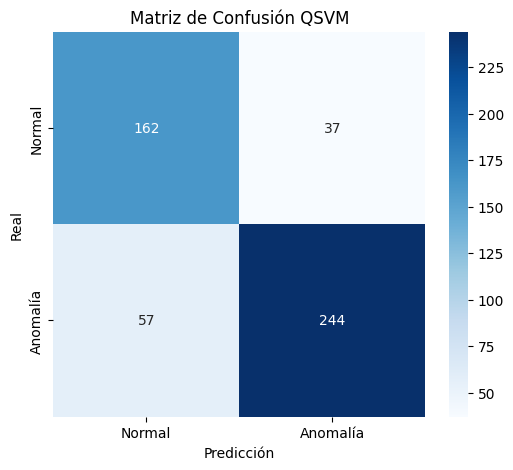

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Matriz de confusión
conf_matrix = confusion_matrix(Y_test, vqc_pred)

# Visualización
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Anomalía'], yticklabels=['Normal', 'Anomalía'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión QSVM')
plt.show()

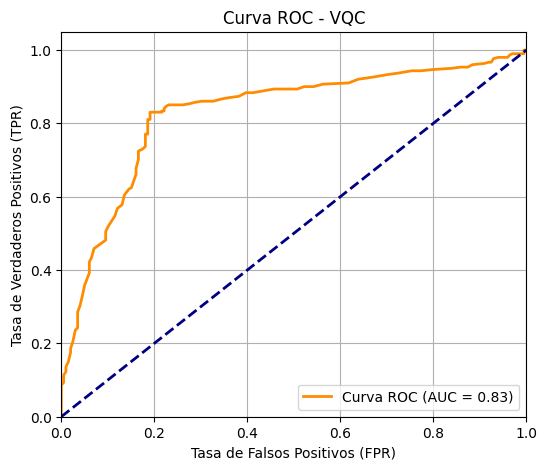

In [17]:
from sklearn.metrics import roc_curve, auc

# Obtén las probabilidades para la clase 1 (anomalía)
vqc_proba = VQC_model.predict_proba(X_test.to_numpy())[:, 1]

fpr, tpr, thresholds = roc_curve(Y_test, vqc_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - VQC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()